In [1]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"


In [2]:
# Parameters
MAX_EPOCHS = 2000
N_SAMPLES = 1
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "/Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/DynFM_metrics_train.csv"


In [3]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


## Dynamic Flow Matching (DynFM) — GP / SPDE

Unified spin-up + physical transport via Flow Matching.
- **Spin-up** (t ∈ [0, SF]): linear interpolant noise → IC (frame 0)
- **Physical** (t ∈ [SF, 1]): linear interpolant frame[k] → frame[k+1]
- Single UNet predicts velocity v(x_t, y, t) → 1 channel output
- No Karras preconditioning — ODE integration preserves diversity naturally

In [4]:
!nvidia-smi

Mon Aug 10 09:03:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.172.08             Driver Version: 570.172.08     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 NVL                Off |   00000000:E3:00.0 Off |                    0 |
| N/A   44C    P0             64W /  400W |       0MiB /  95830MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

In [6]:
import math
import os
import zipfile
import glob
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import xarray as xr
import pandas as pd
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from pytorch_lightning import LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torchinfo import summary

import sys
sys.path.append('../..')      # -> consistency/
sys.path.append('../../..')   # -> 4dvarnet-starter-devs/

from flowmatching_models_FM import (
    UNetFM, UNetFMConfig,
    LogScaleModel, TimeEmbedding,
    neglogpdf, neglogcdf,
    sample_uniform_time, masked_average,
)

try:
    from properscoring import crps_ensemble
    HAS_PROPERSCORING = True
except ImportError:
    HAS_PROPERSCORING = False
    print("properscoring not installed — CRPS disabled.")

## DataModule — SPDE Gaussian Process

Same dataset as DynCM: `window_size` physical frames + sparse observations.

<xarray.Dataset>
Dimensions:    (time: 300, lat: 128, lon: 128)
Coordinates:
  * lon        (lon) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * lat        (lat) int64 0 1 2 3 4 5 6 7 8 ... 120 121 122 123 124 125 126 127
  * time       (time) int64 0 1 2 3 4 5 6 7 ... 292 293 294 295 296 297 298 299
Data variables:
    x          (time, lat, lon) float32 ...
    y          (time, lat, lon) float32 ...
    OI         (time, lat, lon) float64 ...
    H11        (lat, lon) float32 ...
    H22        (lat, lon) float32 ...
    H12        (lat, lon) float32 ...
    Time       (time) int64 ...
    longitude  (lon) int64 ...
    latitude   (lat) int64 ...
Attributes:
    description:  SPDE-based diffusion GP

Variables:
  x: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  y: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float32
  OI: ('time', 'lat', 'lon')  shape=(300, 128, 128)  dtype=float64
  H11: ('lat', 'lon')  shape=(128, 128)  dtype=float32
  H22

[SPDEDataModule] T=300, window=5, stride=1 → 296 windows: train=207, val=44, test=45
[SPDEDataModule] Norm stats (mean, std): (-0.00018237734911963344, 0.249156191945076)
window_size C      = 5
t_IC (transition)  = 0.2000  (= 1/C)
Spatial size       = 128 x 128
TrainingItem: input (y) (5, 128, 128)  tgt (x) (5, 128, 128)


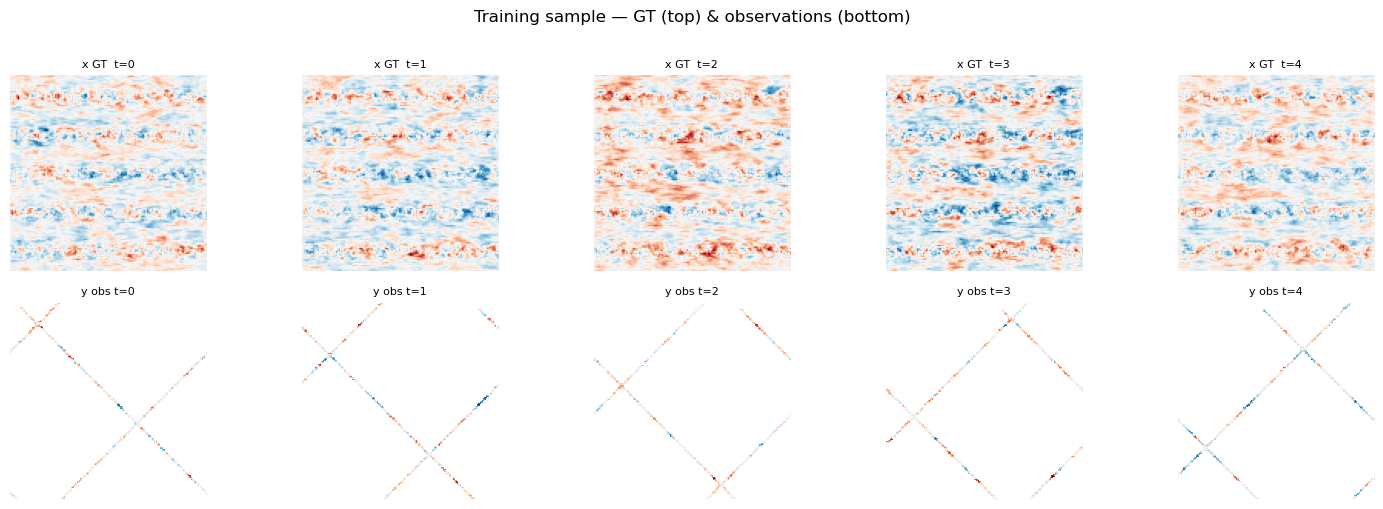

In [7]:
from src.data_notebook_spde import SPDEDataModule

SPDE_PATH = "../../../data/SPDE_diffusion_dataset_1.nc"

ds_inspect = xr.open_dataset(SPDE_PATH)
print(ds_inspect)
print("\nVariables:")
for v in ds_inspect.data_vars:
    print(f"  {v}: {ds_inspect[v].dims}  shape={ds_inspect[v].shape}  dtype={ds_inspect[v].dtype}")
ds_inspect.close()

datamodule = SPDEDataModule(
    path=SPDE_PATH,
    window_size=5,
    stride=1,
    train_ratio=0.7,
    val_ratio=0.15,
    dl_kw={"batch_size": 1, "num_workers": 1},
)
datamodule.setup()

sample = datamodule.train_ds[0]
C  = datamodule.window_size
H, W = sample.tgt.shape[-2], sample.tgt.shape[-1]
t_IC = 1.0 / C   # transition point between spin-up and physical regime

print(f"window_size C      = {C}")
print(f"t_IC (transition)  = {t_IC:.4f}  (= 1/C)")
print(f"Spatial size       = {H} x {W}")
print(f"TrainingItem: input (y) {sample.input.shape}  tgt (x) {sample.tgt.shape}")

fig, axes = plt.subplots(2, C, figsize=(3 * C, 5))
for t_idx in range(C):
    axes[0, t_idx].imshow(sample.tgt[t_idx],   origin="lower", cmap="RdBu_r")
    axes[0, t_idx].set_title(f"x GT  t={t_idx}", fontsize=8)
    axes[0, t_idx].axis("off")
    axes[1, t_idx].imshow(sample.input[t_idx], origin="lower", cmap="RdBu_r")
    axes[1, t_idx].set_title(f"y obs t={t_idx}", fontsize=8)
    axes[1, t_idx].axis("off")
plt.suptitle("Training sample — GT (top) & observations (bottom)", y=1.01)
plt.tight_layout()
plt.show()

### UNetFM for DynFM

- **channels=1** : the ODE state is a single spatial field
- **cond_channels=C** : full observation window as conditioning
- Input: cat(x_t, y_filled, mask) → 1 + 2C channels
- Output: velocity v → 1 channel
- Single time embedding t (no dual t, t' like DynCM)

In [8]:
cfg = UNetFMConfig(channels=1, cond_channels=C)
net = UNetFM(cfg)

summary(
    net,
    input_size=(
        (1, 1, H, W),    # x_t (single frame)
        (1, C, H, W),    # y (full obs window)
        (1,),             # t
    ),
)

Layer (type:depth-idx)                        Output Shape              Param #
UNetFM                                        [1, 1, 128, 128]          --
├─Conv2d: 1-1                                 [1, 64, 128, 128]         6,400
├─TimeEmbedding: 1-2                          [1, 128, 1, 1]            64
│    └─Sequential: 2-1                        [1, 128, 1, 1]            --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
│    │    └─Rearrange: 3-4                    [1, 128, 1, 1]            --
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 64, 128, 128]         --
│    │    └─Sequential: 3-5                   [1, 64, 128, 128]         37,056
│    │    └─Sequential: 3-6                   [1, 64, 1, 1]             8,256
│ 

### DynFM Training — Unified Interpolant

**Timeline** t ∈ [0, 1] with `SF = SPINUP_FRAC`:

| Regime | Time | Interpolant | Velocity target |
|---|---|---|---|
| Spin-up | t ∈ [0, SF] | x(t) = (1−τ)·ε + τ·IC, τ=t/SF | v = (IC − ε) / SF |
| Physical | t ∈ [SF, 1] | x(t) = (1−α)·f[k] + α·f[k+1] | v = (f[k+1] − f[k])·(C−1)/(1−SF) |

At inference, Heun ODE integration from t=0 (noise) to t=1 extracts physical frames at
t_k = SF + k·(1−SF)/(C−1) for k=0,...,C−1.

In [9]:
SPINUP_FRAC = 0.3

@dataclass
class LitDynFMConfig:
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    ema_decay: float = 0.999
    spinup_frac: float = 0.3
    eval_n_steps: int = 40
    loss_type: str = "mse"           # "mse" or "log_scale"
    precondition: bool = True        # velocity preconditioning (c_out scaling)


class LitDynFM(LightningModule):

    def __init__(self, network: UNetFM, config: LitDynFMConfig,
                 n_log_scale_embedding: int = 128):
        super().__init__()
        self.network = network
        self.config  = config
        self.sf      = config.spinup_frac
        self.precondition = config.precondition
        self.use_log_scale = config.loss_type == "log_scale"
        if self.use_log_scale:
            self.log_scale = LogScaleModel(n_log_scale_embedding, n_vars=1)
        self.ema_model = torch.optim.swa_utils.AveragedModel(
            network,
            multi_avg_fn=torch.optim.swa_utils.get_ema_multi_avg_fn(config.ema_decay),
            device="cpu",
        )
        self.ema_model.requires_grad_(False)
        self.ema_model.eval()
        self._val_batch = None

    def on_fit_start(self):
        try:
            dl = self.trainer.datamodule.val_dataloader()
            batch = next(iter(dl))
            if isinstance(batch, list): batch = batch[0]
            self._val_batch = batch
            print(f"Val batch cached: tgt={batch.tgt.shape}")
        except Exception as e:
            print(f"Could not cache val batch: {e}")

    def on_train_batch_end(self, outputs, batch, batch_idx):
        self.ema_model.update_parameters(self.network)

    def _build_interpolant(self, x_full, t, noise):
        B, C, H, W = x_full.shape
        SF = self.sf
        is_spinup = t < SF

        # Spin-up: noise -> IC (frame 0)
        tau_s = (t / SF).clamp(0, 1).view(B, 1, 1, 1)
        ic = x_full[:, [0], :, :]
        xt_s = (1 - tau_s) * noise + tau_s * ic
        vt_s = (ic - noise) / SF

        # Physical: frame[k] -> frame[k+1]
        tau_p = ((t - SF) / (1 - SF)).clamp(0, 1)
        fpos = tau_p * (C - 1)
        k = fpos.long().clamp(0, C - 2)
        alpha = (fpos - k.float()).view(B, 1, 1, 1)
        b_idx = torch.arange(B, device=x_full.device)
        f_k  = x_full[b_idx, k].unsqueeze(1)
        f_k1 = x_full[b_idx, (k + 1).clamp(max=C - 1)].unsqueeze(1)
        xt_p = (1 - alpha) * f_k + alpha * f_k1
        vt_p = (f_k1 - f_k) * (C - 1) / (1 - SF)

        is_s = is_spinup.view(B, 1, 1, 1)
        x_t      = torch.where(is_s, xt_s, xt_p)
        v_target = torch.where(is_s, vt_s, vt_p)

        c_out = torch.where(
            is_spinup,
            torch.tensor(1.0 / SF, device=x_full.device, dtype=x_full.dtype),
            torch.tensor(float(C - 1) / (1.0 - SF), device=x_full.device, dtype=x_full.dtype),
        ).view(B, 1, 1, 1)

        return x_t, v_target, c_out

    def training_step(self, batch, batch_idx):
        if isinstance(batch, list): batch = batch[0]
        x_full = batch.tgt
        y      = batch.input
        B, C, H, W = x_full.shape

        t = sample_uniform_time(x_full).view(B)
        noise = torch.randn(B, 1, H, W, device=x_full.device, dtype=x_full.dtype)

        x_t, v_target, c_out = self._build_interpolant(x_full, t, noise)
        v_pred = self.network(x_t, y, t)

        if self.precondition:
            v_target = v_target / c_out

        if self.use_log_scale:
            log_s = self.log_scale(t).view(B, 1, 1, 1).expand_as(v_pred)
            residual = (v_target - v_pred) / log_s.exp().clamp(min=1e-5)
            loss = neglogpdf(residual, log_s).mean()
        else:
            loss = F.mse_loss(v_pred, v_target)

        self.log("train_loss", loss, prog_bar=True, on_step=True, on_epoch=True)
        return loss

    def on_train_epoch_end(self):
        if self._val_batch is None: return
        device = self.device
        dtype  = next(self.network.parameters()).dtype
        x_gt = self._val_batch.tgt.to(device=device, dtype=dtype)
        y    = self._val_batch.input.to(device=device, dtype=dtype)
        B, C, H, W = x_gt.shape

        ema_net = self.ema_model.module.to(device=device, dtype=dtype)
        ema_net.eval()

        noise = torch.randn(B, 1, H, W, device=device, dtype=dtype)
        _, traj, traj_times = dynfm_heun_sample(ema_net, noise, y,
                                    n_steps=self.config.eval_n_steps,
                                    spinup_frac=self.sf, precondition=self.precondition)
        frames = extract_dynfm_frames(traj, traj_times, C, self.sf)
        x_hat = torch.cat(frames, dim=1)

        rmse = (x_hat.float() - x_gt.float()).pow(2).mean().sqrt().item()
        print(f"[Epoch {self.current_epoch}]  Val RMSE (DynFM, EMA) = {rmse:.4f}")
        self.log("val_rmse_ema", rmse)

    def configure_optimizers(self):
        params = list(self.network.parameters())
        if self.use_log_scale:
            params += list(self.log_scale.parameters())
        opt   = torch.optim.Adam(params, lr=self.config.lr, betas=self.config.betas)
        sched = torch.optim.lr_scheduler.LinearLR(
            opt, start_factor=self.config.lr_scheduler_start_factor,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step", "frequency": 1}]


print("LitDynFM defined")

LitDynFM defined


In [10]:
@torch.no_grad()
def dynfm_heun_sample(model, noise, y, n_steps=40, spinup_frac=0.3, precondition=True):
    """Heun (RK2) ODE sampling with boundary-aware time grid.

    Inserts the spinup/physical boundary (t=SF) and frame-boundary times
    into the integration grid so that no single Heun step straddles a
    c_out discontinuity or a velocity-target transition.
    """
    C_obs = y.shape[1]
    SF = spinup_frac
    c_out_s = 1.0 / SF
    c_out_p = float(C_obs - 1) / (1.0 - SF)

    # Uniform grid + regime boundaries (SF, frame times)
    boundaries = {SF}
    for k in range(C_obs):
        boundaries.add(SF + (1.0 - SF) * k / max(C_obs - 1, 1))
    uniform_times = {i / n_steps for i in range(n_steps + 1)}
    all_times = sorted(uniform_times | boundaries)

    x = noise.clone()
    traj = [x.clone()]
    traj_times = [0.0]

    for i in range(len(all_times) - 1):
        t0 = all_times[i]
        t1 = all_times[i + 1]
        dt = t1 - t0
        if dt < 1e-10:
            continue

        t0_t = torch.full((x.size(0),), t0, device=x.device, dtype=x.dtype)
        t1_t = torch.full((x.size(0),), t1, device=x.device, dtype=x.dtype)

        v0 = model(x, y, t0_t)
        if precondition:
            v0 = v0 * (c_out_s if t0 < SF else c_out_p)

        x1_pred = x + dt * v0

        v1 = model(x1_pred, y, t1_t)
        if precondition:
            v1 = v1 * (c_out_s if t1 < SF else c_out_p)

        x = x + dt * 0.5 * (v0 + v1)
        traj.append(x.clone())
        traj_times.append(t1)

    return x, traj, traj_times


def extract_dynfm_frames(traj, traj_times, C, spinup_frac=0.3):
    """Extract the C physical frames from a trajectory using traj_times."""
    SF = spinup_frac
    frame_times = [SF + k * (1 - SF) / max(C - 1, 1) for k in range(C)]
    times_arr = np.array(traj_times)
    frame_indices = [int(np.argmin(np.abs(times_arr - ft))) for ft in frame_times]
    return [traj[idx] for idx in frame_indices]


n_actual = len(sorted({i / 40 for i in range(41)} | {SPINUP_FRAC} |
               {SPINUP_FRAC + k*(1-SPINUP_FRAC)/max(C-1,1) for k in range(C)})) - 1
print(f"Sampling functions defined (boundary-aware grid)")
print(f"  n_steps=40 → {n_actual} actual Heun steps (with {C+1} boundary points inserted)")
print(f"Frame extraction times (C={C}, SF={SPINUP_FRAC}):")
for k in range(C):
    ft = SPINUP_FRAC + k * (1 - SPINUP_FRAC) / max(C - 1, 1)
    print(f"  frame[{k}] @ t={ft:.3f}")

Sampling functions defined (boundary-aware grid)
  n_steps=40 → 41 actual Heun steps (with 6 boundary points inserted)
Frame extraction times (C=5, SF=0.3):
  frame[0] @ t=0.300
  frame[1] @ t=0.475
  frame[2] @ t=0.650
  frame[3] @ t=0.825
  frame[4] @ t=1.000


## Training

In [11]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False

def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last) and is_valid_checkpoint(last):
        print(f"Valid checkpoint: {last}")
        return last
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt")) if "last" not in p],
        key=lambda p: float(p.split("train_loss=")[-1].replace(".ckpt", ""))
        if "train_loss=" in p else float("inf"),
    )
    for p in all_ckpts:
        if is_valid_checkpoint(p):
            print(f"Valid checkpoint: {p}")
            return p
    print("No valid checkpoint found. Starting from scratch.")
    return None

LOG_DIR     = "logs_DynFM_spde"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
MODEL_PATH  = os.path.join(LOG_DIR, "best_model")

# RESET_TRAINING set by the parameters cell above
if RESET_TRAINING:
    import shutil
    for d in [CKPT_DIR, MODEL_PATH]:
        if os.path.exists(d):
            shutil.rmtree(d)
    resume_ckpt = None
    print("RESET_TRAINING=True -- starting from scratch")
else:
    resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

network = UNetFM(UNetFMConfig(channels=1, cond_channels=C))
lit_dynfm = LitDynFM(
    network=network,
    config=LitDynFMConfig(
        lr_scheduler_iters=1000,
        eval_n_steps=4*C+1,
        spinup_frac=SPINUP_FRAC,
        loss_type="mse",
        precondition=True,
    ),
)

trainer = Trainer(enable_progress_bar=False, 
    accelerator="gpu",
    max_epochs=MAX_EPOCHS,
    accumulate_grad_batches=4,
    precision="16-mixed",
    log_every_n_steps=1,
    logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
    callbacks=[
        LearningRateMonitor(logging_interval="step"),
        ModelCheckpoint(
            dirpath=CKPT_DIR,
            monitor="train_loss",
            save_top_k=3,
            save_last=True,
            filename="{epoch:03d}-{step}-{train_loss:.4f}",
        ),
    ],
)

seed_everything(42)
trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
trainer.fit(lit_dynfm, datamodule, ckpt_path=resume_ckpt)

ema_net = lit_dynfm.ema_model.module
ema_net.save_pretrained(MODEL_PATH)
print(f"EMA model saved to: {MODEL_PATH}")

Valid checkpoint: logs_DynFM_spde/checkpoints/last.ckpt


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/lightning_fabric/plugins/environments/slurm.py:168: PossibleUserWarning: The `srun` command is available on your system but is not used. HINT: If your intention is to run Lightning on SLURM, prepend your python command with `srun` like so: srun python /Odyssey/private/m19beauc/conda_envs/4dvarnet-starte ...
  rank_zero_warn(
Using 16bit Automatic Mixed Precision (AMP)


/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


...

[Epoch 1998]  Val RMSE (DynFM, EMA) = 1.0388


[progress] epoch 2000/2000 | train_loss=0.0968 | train_loss_epoch=0.0968 | train_loss_step=0.0414 | val_rmse_ema=1.0388


[Epoch 1999]  Val RMSE (DynFM, EMA) = 1.0455


`Trainer.fit` stopped: `max_epochs=2000` reached.


EMA model saved to: logs_DynFM_spde/best_model


## Sampling & Evaluation

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
dtype  = torch.float32

MODEL_PATH = os.path.join("logs_DynFM_spde", "best_model")

ema_unet = UNetFM.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
print(f"EMA UNetFM loaded from {MODEL_PATH}")

EMA UNetFM loaded from logs_DynFM_spde/best_model


### Test Batch

In [13]:
seed_everything(42)
batch = next(iter(datamodule.test_dataloader()))
C = batch.tgt.shape[1]
H, W = batch.tgt.shape[-2], batch.tgt.shape[-1]
y_obs = batch.input.to(device=device, dtype=dtype)
m_norm, s_norm = datamodule.norm_stats()
print(f"Test batch: tgt={batch.tgt.shape}, input={batch.input.shape}")

[rank: 0] Global seed set to 42


Test batch: tgt=torch.Size([1, 5, 128, 128]), input=torch.Size([1, 5, 128, 128])


### Ensemble Generation

In [14]:
# N_SAMPLES set by the parameters cell above
N_STEPS   = 4 * C + 1

all_frames = []

with torch.no_grad():
    for s in range(N_SAMPLES):
        noise = torch.randn(1, 1, H, W, device=device, dtype=dtype)
        _, traj, traj_times = dynfm_heun_sample(ema_unet, noise, y_obs[0:1], n_steps=N_STEPS,
                                    spinup_frac=SPINUP_FRAC, precondition=True)
        frames = extract_dynfm_frames(traj, traj_times, C, SPINUP_FRAC)
        member = torch.cat(frames, dim=1)   # (1, C, H, W)
        all_frames.append(member.cpu())
        print(f"  member {s+1}/{N_SAMPLES}", end="\r")

ensemble = torch.cat(all_frames, dim=0)    # (N, C, H, W)
ens_mean = ensemble.mean(0)                 # (C, H, W)
ens_std  = ensemble.std(0)
print(f"\nEnsemble: {tuple(ensemble.shape)}")

  member 1/1
Ensemble: (1, 5, 128, 128)


/tmp/ipykernel_998657/364050858.py:18: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1879.)
  ens_std  = ensemble.std(0)


In [15]:
# Full trajectory for member 0 (for transport visualisation)
torch.manual_seed(42)
noise_viz = torch.randn(1, 1, H, W, device=device, dtype=dtype)
with torch.no_grad():
    _, traj_viz, traj_times_viz = dynfm_heun_sample(ema_unet, noise_viz, y_obs[0:1],
                                    n_steps=N_STEPS, spinup_frac=SPINUP_FRAC,
                                    precondition=True)

# Physical frame stack
gt_np     = batch.tgt[0].float().numpy()
ens_mean_traj = ens_mean.float().numpy()
ens_std_traj  = ens_std.float().numpy()
print(f"GT: {gt_np.shape}, ens_mean: {ens_mean_traj.shape}")
print(f"Trajectory: {len(traj_viz)} steps (boundary-aware grid)")

GT: (5, 128, 128), ens_mean: (5, 128, 128)
Trajectory: 26 steps (boundary-aware grid)


### Publication Figures

/Odyssey/private/m19beauc/conda_envs/4dvarnet-starter/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


  Saved: figures/DynFM_spde/DynFM_spde_obs.png


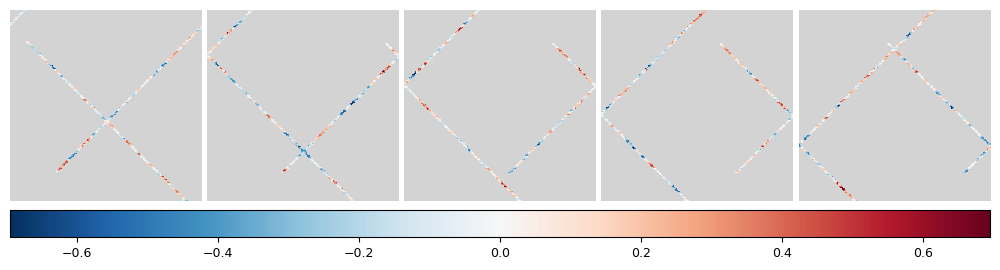

  Saved: figures/DynFM_spde/DynFM_spde_gt.png


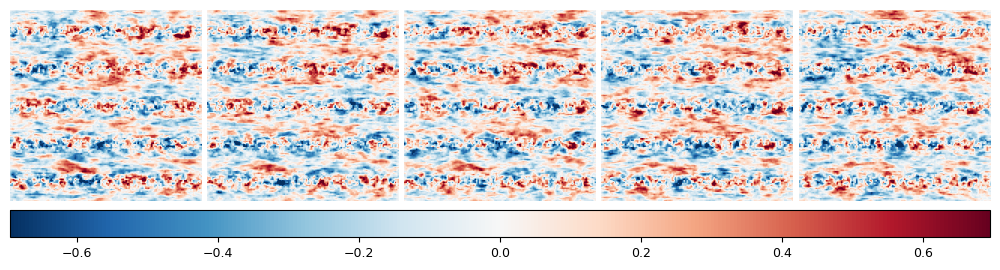

  Saved: figures/DynFM_spde/DynFM_spde_mean.png


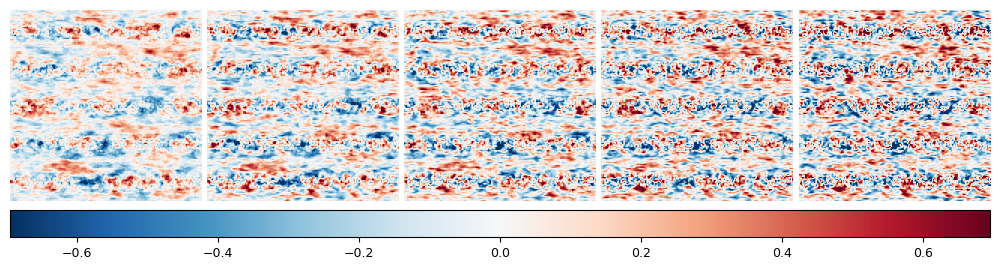

  Saved: figures/DynFM_spde/DynFM_spde_spread.png


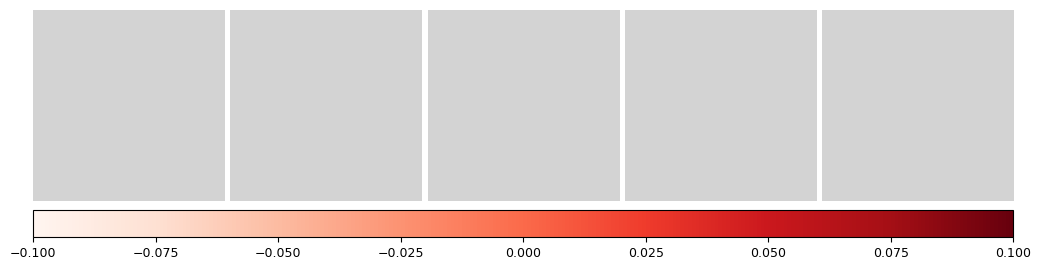

  Saved: figures/DynFM_spde/DynFM_spde_member0.png


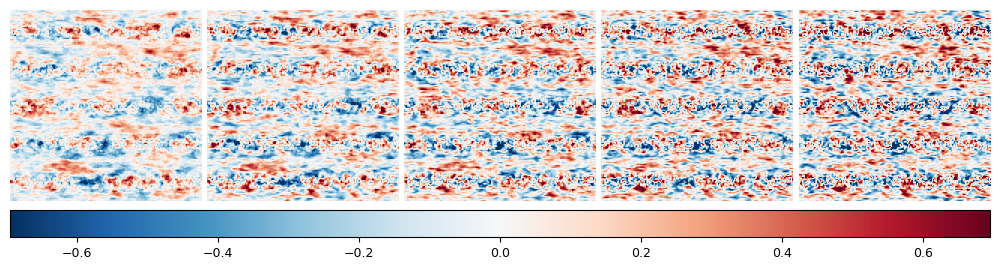

In [16]:
from matplotlib.gridspec import GridSpec

FIG_TAG = 'DynFM_spde'
FIG_DIR = os.path.join('figures', FIG_TAG)
os.makedirs(FIG_DIR, exist_ok=True)

obs_phys  = batch.input[0].float().numpy() * s_norm + m_norm
gt_phys   = batch.tgt[0].float().numpy()   * s_norm + m_norm
mean_phys = ens_mean.float().numpy()        * s_norm + m_norm
std_phys  = ens_std.float().numpy()         * s_norm
mbr0_phys = ensemble[0].float().numpy()     * s_norm + m_norm

vmax_f = float(np.nanpercentile(np.abs(gt_phys), 99))
vmin_f = -vmax_f
vmax_s = float(np.nanpercentile(std_phys, 99))

cmap_f = plt.cm.RdBu_r.copy(); cmap_f.set_bad('lightgray')
cmap_s = plt.cm.Reds.copy();   cmap_s.set_bad('lightgray')

def _save_strip(data, filename, vmin, vmax, cmap):
    nc = data.shape[0]
    FW, FH, CB_H = 2.0, 2.0, 0.28
    fig = plt.figure(figsize=(nc*FW, FH+CB_H+0.06))
    gs = GridSpec(2, nc, left=0.01, right=0.99, top=0.99, bottom=0.01,
                  height_ratios=[FH, CB_H], hspace=0.06, wspace=0.03)
    for c in range(nc):
        ax = fig.add_subplot(gs[0, c])
        ax.imshow(data[c], origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
        ax.axis('off')
    ax_cb = fig.add_subplot(gs[1, :])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, cax=ax_cb, orientation='horizontal').ax.tick_params(labelsize=9)
    fpath = os.path.join(FIG_DIR, f'{filename}.png')
    fig.savefig(fpath, dpi=200, bbox_inches='tight')
    print(f'  Saved: {fpath}'); plt.show()

for data, fname, vmin, vmax, cmap in [
    (obs_phys,  f'{FIG_TAG}_obs',      vmin_f, vmax_f, cmap_f),
    (gt_phys,   f'{FIG_TAG}_gt',       vmin_f, vmax_f, cmap_f),
    (mean_phys, f'{FIG_TAG}_mean',     vmin_f, vmax_f, cmap_f),
    (std_phys,  f'{FIG_TAG}_spread',   0,      vmax_s, cmap_s),
    (mbr0_phys, f'{FIG_TAG}_member0',  vmin_f, vmax_f, cmap_f),
]:
    _save_strip(data, fname, vmin, vmax, cmap)

### Transport Process — ODE trajectory

Full trajectory from noise (t=0) through spin-up → IC → physical frames.
Vertical dashed line marks the spin-up / physical boundary.

step_indices (13 cols) = [0, 2, 4, 6, 7, 9, 11, 13, 16, 18, 21, 23, 25]
phys_col                   = [4, 6, 8, 10, 12]
spinup_cols                = [0, 1, 2, 3]


  Saved: figures/DynFM_spde/DynFM_spde_transport.png


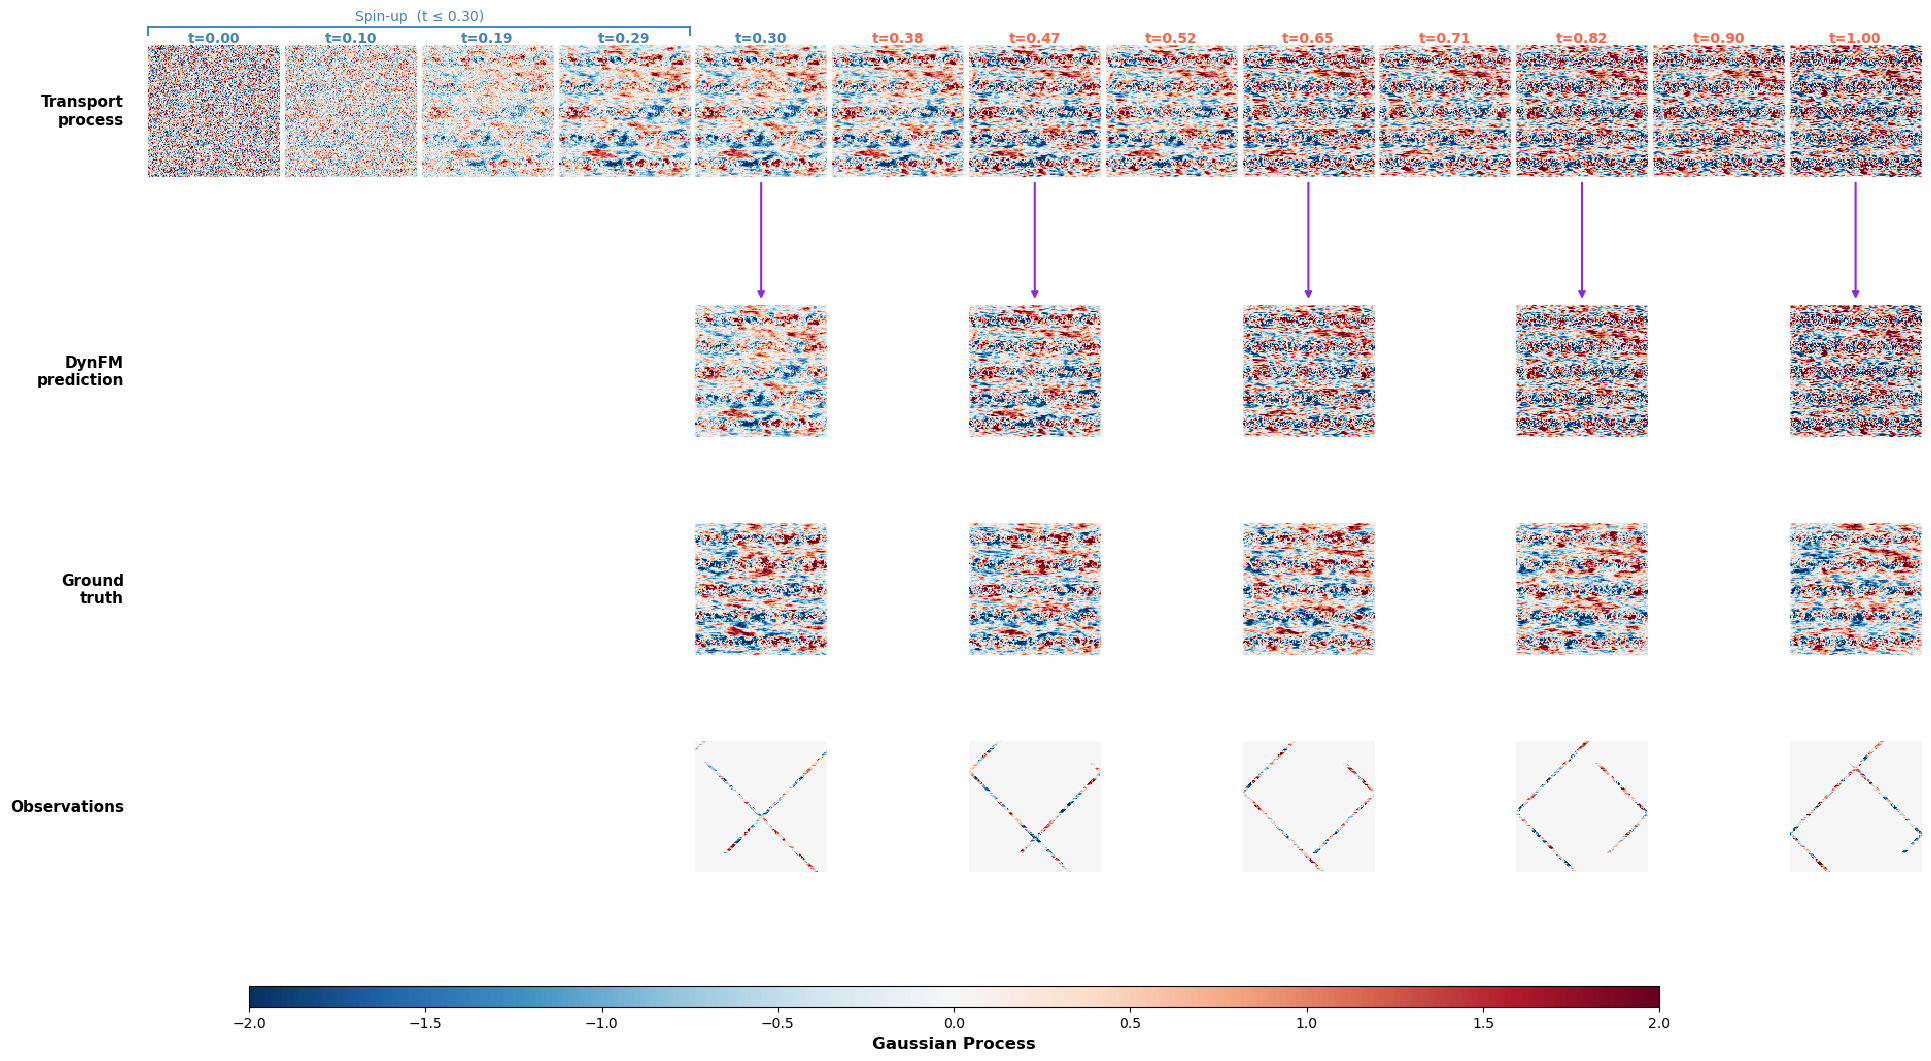

  Saved: figures/DynFM_spde/DynFM_spde_variance_collapse.png


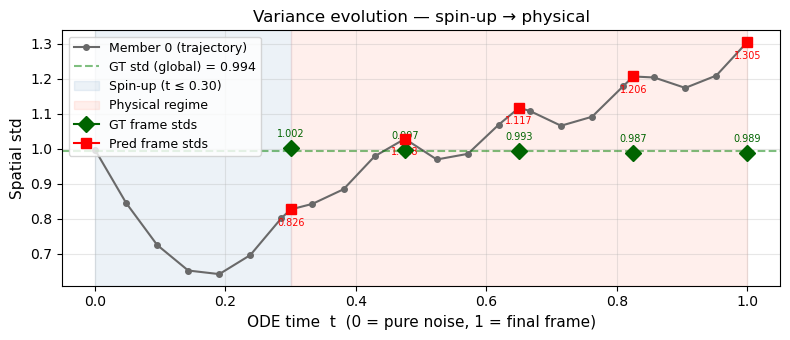


Std step 0 (noise): 0.9969   Std last step: 1.3052   GT std (global): 0.9939
Per-frame GT stds:  ['1.0020', '0.9968', '0.9932', '0.9867', '0.9887']
Per-frame pred stds: ['0.8262', '1.0281', '1.1168', '1.2065', '1.3052']


In [17]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

# ── Build process tensor from traj_viz ─────────────────────────────────────────
proc = torch.stack(traj_viz, dim=0)[:, 0, 0, :, :]   # (n_actual+1, H, W)
nfr  = proc.shape[0]
t_viz = np.array(traj_times_viz)

def solver_time(si):
    return round(t_viz[si], 3)

# ── Physical frame indices (using traj_times_viz) ─────────────────────────────
SF = SPINUP_FRAC
frame_times = [SF + k * (1 - SF) / max(C - 1, 1) for k in range(C)]
phys_indices_list = [int(np.argmin(np.abs(t_viz - ft))) for ft in frame_times]

phys_frames    = proc[phys_indices_list].cpu().numpy()        # (C, H, W)
phys_times_lst = [solver_time(i) for i in phys_indices_list]
gt_phys_frames = batch.tgt[0].float().numpy()
obs_frames     = np.nan_to_num(batch.input[0].float().numpy(), nan=0.0)

vmin_all, vmax_all = -2, 2

# ── Build step_indices ─────────────────────────────────────────────────────────
phys0        = phys_indices_list[0]
N_SPINUP_COL = 4
spinup_steps = sorted({
    round(k * (phys0 - 1) / max(N_SPINUP_COL - 1, 1))
    for k in range(N_SPINUP_COL)
    if round(k * (phys0 - 1) / max(N_SPINUP_COL - 1, 1)) < phys0
})

phys_and_intermed = []
for k, pi in enumerate(phys_indices_list):
    phys_and_intermed.append(pi)
    if k < len(phys_indices_list) - 1:
        mid = int((pi + phys_indices_list[k + 1]) / 2)
        phys_and_intermed.append(mid)

step_indices         = spinup_steps + phys_and_intermed
step_indices_display = step_indices
n_top                = len(step_indices_display)

phys_step_set = set(phys_indices_list)
spinup_cols   = [j for j, si in enumerate(step_indices_display)
                 if si not in phys_step_set and t_viz[si] <= SF + 1e-6]

phys_col = [step_indices_display.index(pi) for pi in phys_indices_list]

print(f"step_indices ({n_top} cols) = {step_indices}")
print(f"phys_col                   = {phys_col}")
print(f"spinup_cols                = {spinup_cols}")

# ── Figure layout ──────────────────────────────────────────────────────────────
FIG_W   = max(n_top * 1.55, 18)
FIG_H   = 11.5
PUB_FS  = 11
TOP_FS  = 10

fig = plt.figure(figsize=(FIG_W, FIG_H))
gs  = fig.add_gridspec(
    4, n_top,
    height_ratios=[3, 2, 2, 2],
    hspace=0.25, wspace=0.04,
    left=0.10, right=0.98, top=0.93, bottom=0.14,
)

axes_top = [fig.add_subplot(gs[0, j]) for j in range(n_top)]
axes_mid = {k: fig.add_subplot(gs[1, col]) for k, col in enumerate(phys_col)}
axes_bot = {k: fig.add_subplot(gs[2, col]) for k, col in enumerate(phys_col)}
axes_obs = {k: fig.add_subplot(gs[3, col]) for k, col in enumerate(phys_col)}

# ── Row 0: transport strip ────────────────────────────────────────────────────
for j, si in enumerate(step_indices_display):
    ax    = axes_top[j]
    s_val = t_viz[si]
    ax.imshow(proc[si].cpu().numpy(), origin="lower",
              cmap="RdBu_r", vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    col_t = "steelblue" if s_val <= SF + 1e-6 else "tomato"
    ax.set_title(f"t={s_val:.2f}", fontsize=TOP_FS, color=col_t, pad=2, fontweight="bold")
    ax.axis("off")
    if si in phys_step_set:
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_edgecolor("limegreen"); sp.set_linewidth(2.5)

# ── Rows 1–3: prediction / GT / obs ──────────────────────────────────────────
for k in range(C):
    axes_mid[k].imshow(phys_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_mid[k].axis("off")
    for sp in axes_mid[k].spines.values():
        sp.set_visible(True); sp.set_edgecolor("limegreen"); sp.set_linewidth(2)

    axes_bot[k].imshow(gt_phys_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_bot[k].axis("off")

    axes_obs[k].imshow(obs_frames[k], origin="lower", cmap="RdBu_r",
                       vmin=vmin_all, vmax=vmax_all, interpolation="nearest")
    axes_obs[k].axis("off")

# ── Row labels ────────────────────────────────────────────────────────────────
fig.canvas.draw()
label_x = axes_top[0].get_position().x0 - 0.012
rows_meta = [
    (axes_top[0],  "Transport\nprocess"),
    (axes_mid[0],  "DynFM\nprediction"),
    (axes_bot[0],  "Ground\ntruth"),
    (axes_obs[0],  "Observations"),
]
for ax_ref, lbl in rows_meta:
    pos = ax_ref.get_position()
    yc  = (pos.y0 + pos.y1) / 2
    fig.text(label_x, yc, lbl, va="center", ha="right",
             fontsize=PUB_FS, color="black", fontweight="bold", rotation=0,
             fontfamily="DejaVu Sans")

# ── Arrows: transport strip → prediction row ─────────────────────────────────
for k, col in enumerate(phys_col):
    sb = axes_top[col].get_position()
    db = axes_mid[k].get_position()
    xm = (sb.x0 + sb.x1) / 2
    fig.add_artist(mpatches.FancyArrowPatch(
        (xm, sb.y0 - 0.003), (xm, db.y1 + 0.003),
        transform=fig.transFigure, arrowstyle="-|>",
        color="blueviolet", mutation_scale=10, linewidth=1.5,
    ))

# ── Spin-up brace above top strip ────────────────────────────────────────────
if spinup_cols:
    p0   = axes_top[spinup_cols[0]].get_position()
    p1   = axes_top[spinup_cols[-1]].get_position()
    xL, xR = p0.x0, p1.x1
    yT   = p0.y1 + 0.016
    th   = 0.007
    for xt in [xL, xR]:
        fig.add_artist(plt.Line2D([xt, xt], [yT, yT - th],
            transform=fig.transFigure, color="steelblue", linewidth=1.4, clip_on=False))
    fig.add_artist(plt.Line2D([xL, xR], [yT, yT],
        transform=fig.transFigure, color="steelblue", linewidth=1.4, clip_on=False))
    fig.text((xL + xR) / 2, yT + 0.003,
             f"Spin-up  (t ≤ {SF:.2f})",
             ha="center", va="bottom", fontsize=PUB_FS - 1, color="steelblue")

# ── Horizontal colorbar at bottom ────────────────────────────────────────────
cbar_ax = fig.add_axes([0.15, 0.04, 0.70, 0.018])
sm = plt.cm.ScalarMappable(cmap="RdBu_r",
                            norm=plt.Normalize(vmin=vmin_all, vmax=vmax_all))
sm.set_array([])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Gaussian Process", fontsize=PUB_FS + 1, fontweight="bold")
cbar.ax.tick_params(labelsize=PUB_FS - 1)

fpath = os.path.join(FIG_DIR, f'{FIG_TAG}_transport.png')
fig.savefig(fpath, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath}')
plt.show()

# ── Variance collapse with per-frame GT stds ─────────────────────────────────
step_stds = np.array([proc[k].cpu().numpy().std() for k in range(nfr)])
gt_std    = batch.tgt[0].float().numpy().std()
gt_frame_stds = [batch.tgt[0, k].float().numpy().std() for k in range(C)]

fig2, ax2 = plt.subplots(figsize=(8, 3.5))
ax2.plot(t_viz, step_stds, marker="o", markersize=4, color="dimgray", label="Member 0 (trajectory)")
ax2.axhline(gt_std, color="green", linestyle="--", alpha=0.5, label=f"GT std (global) = {gt_std:.3f}")
ax2.axvspan(0.0, SF, alpha=0.10, color="steelblue",
            label=f"Spin-up (t ≤ {SF:.2f})")
ax2.axvspan(SF, 1.0, alpha=0.10, color="tomato", label="Physical regime")

for k, (ft, gs) in enumerate(zip(frame_times, gt_frame_stds)):
    lbl = f"GT frame stds" if k == 0 else None
    ax2.plot(ft, gs, marker='D', color='darkgreen', markersize=8, zorder=5, label=lbl)
    ax2.annotate(f'{gs:.3f}', (ft, gs), textcoords="offset points",
                 xytext=(0, 8), ha='center', fontsize=7, color='darkgreen')

for k, (ft, pi) in enumerate(zip(frame_times, phys_indices_list)):
    pred_std = step_stds[pi]
    lbl = f"Pred frame stds" if k == 0 else None
    ax2.plot(ft, pred_std, marker='s', color='red', markersize=7, zorder=5, label=lbl)
    ax2.annotate(f'{pred_std:.3f}', (ft, pred_std), textcoords="offset points",
                 xytext=(0, -12), ha='center', fontsize=7, color='red')

ax2.set_xlabel("ODE time  t  (0 = pure noise, 1 = final frame)", fontsize=PUB_FS)
ax2.set_ylabel("Spatial std", fontsize=PUB_FS)
ax2.set_title("Variance evolution — spin-up → physical", fontsize=PUB_FS + 1)
ax2.legend(fontsize=PUB_FS - 2, loc='upper left')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
fpath2 = os.path.join(FIG_DIR, f'DynFM_spde_variance_collapse.png')
fig2.savefig(fpath2, dpi=200, bbox_inches='tight')
print(f'  Saved: {fpath2}')
plt.show()

print(f"\nStd step 0 (noise): {step_stds[0]:.4f}   Std last step: {step_stds[-1]:.4f}   GT std (global): {gt_std:.4f}")
print(f"Per-frame GT stds:  {['%.4f' % s for s in gt_frame_stds]}")
print(f"Per-frame pred stds: {['%.4f' % step_stds[pi] for pi in phys_indices_list]}")

## Metrics — DynFM vs GT

| Metric | Description |
|---|---|
| **Score** | $1 - \text{RMSE}/\sigma_{\text{GT}}$ |
| **RMSE** | Root Mean Square Error |
| **CRPS** | Continuous Ranked Probability Score |
| **lambda_x** | Resolved scale at spectral score = 0.5 |

[rank: 0] Global seed set to 42


Evaluated 225 (test sample, timestep) pairs across the full test set

## Metrics -- full test set (whole domain), n=225 (sample,t) pairs



,Score,RMSE,sigma_GT,sigma_pred,CRPS,lambda_x [px]
Method,,,,,,
"DynFM (ens. mean, full test set)",-0.088 ± 0.166,0.2711 ± 0.0419,0.2492 ± 0.0058,0.2743 ± 0.0456,0.0229 ± 0.0090,39.3 ± 28.7


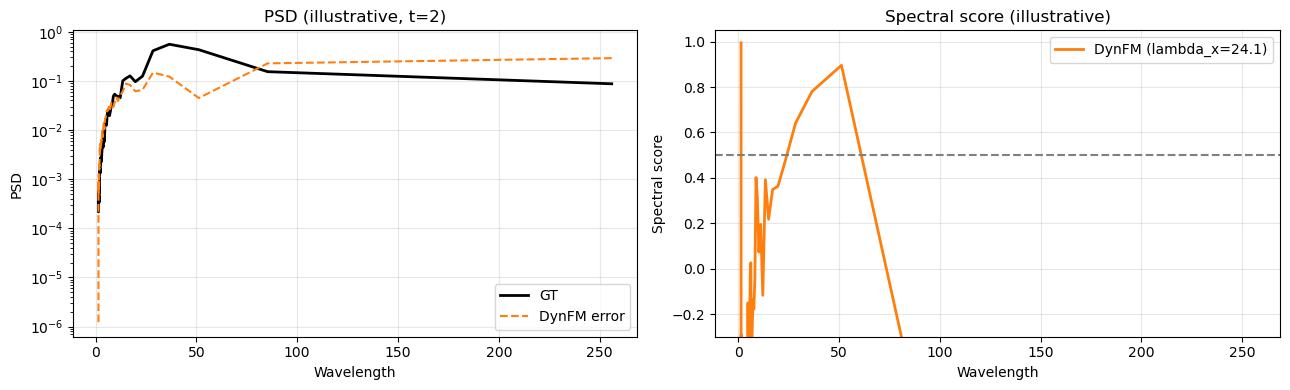

In [18]:
import sys
sys.path.append('../..')
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale

DX = 1.0   # pixel spacing

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative figures above) and EVERY timestep of the
# assimilation window (not just T_EVAL=C//2), regenerating a fresh ensemble
# each time via the DynFM boundary-aware Heun sampler. This is the expensive
# part (N_SAMPLES x n_test_samples ODE integrations) -- N_SAMPLES was reduced
# from 50 to 20 in methods.yaml specifically to keep a full-test-set pass
# affordable. SSH_GF is a continuous z-scored field, so unlike SIC there is
# no MIZ-style domain restriction -- metrics are aggregated over the whole
# spatial domain.
_all = {'score': [], 'rmse': [], 'sigma_gt': [], 'sigma_pred': [], 'crps': [], 'lambda_x': []}
_n_pairs = 0

seed_everything(42)
for _tb in datamodule.test_dataloader():
    _gt_b = _tb.tgt.to(device=device, dtype=dtype)     # (B, C, H, W)
    _y_b  = _tb.input.to(device=device, dtype=dtype)    # (B, C, H, W)
    _Bb, _Cb, _Hb, _Wb = _gt_b.shape
    _valid_b   = ~torch.isnan(_gt_b)
    _obsmask_b = ~torch.isnan(_y_b)

    for _bi in range(_Bb):
        with torch.no_grad():
            _members = []
            for _s in range(N_SAMPLES):
                _noise = torch.randn(1, 1, _Hb, _Wb, device=device, dtype=dtype)
                _, _traj, _traj_times = dynfm_heun_sample(
                    ema_unet, _noise, _y_b[_bi:_bi + 1], n_steps=N_STEPS,
                    spinup_frac=SPINUP_FRAC, precondition=True,
                )
                _frames = extract_dynfm_frames(_traj, _traj_times, _Cb, SPINUP_FRAC)
                _member = torch.cat(_frames, dim=1)   # (1, C, H, W)
                _members.append(_member.cpu())
        _ens_b = torch.cat(_members, dim=0)            # (N, C, H, W) normalised
        _ens_mean_b = _ens_b.mean(0)                    # (C, H, W)

        for _t in range(_Cb):
            _valid_t = _valid_b[_bi, _t].cpu().numpy()
            if _valid_t.sum() < 10:
                continue
            _gt_p   = _gt_b[_bi, _t].float().cpu().numpy() * s_norm + m_norm
            _mean_p = _ens_mean_b[_t].float().numpy()      * s_norm + m_norm
            _ens_p  = _ens_b[:, _t].float().numpy()        * s_norm + m_norm

            _gt_v, _pred_v = _gt_p[_valid_t], _mean_p[_valid_t]
            _sigma = float(np.std(_gt_v))
            if _sigma <= 0:
                continue
            _rmse  = float(np.sqrt(np.mean((_pred_v - _gt_v) ** 2)))
            _score = 1.0 - _rmse / _sigma
            _sigma_pred = float(np.std(_pred_v))

            _gt_f   = np.nan_to_num(_gt_p,   nan=0.0)
            _pred_f = np.nan_to_num(_mean_p, nan=0.0)
            _wl, _, _, _spec = psd_spectral_score(_pred_f, _gt_f, dx=DX)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)

            _crps_val = np.nan
            if HAS_PROPERSCORING:
                _obs_t  = _obsmask_b[_bi, _t].cpu().numpy()
                _obs_ij = np.argwhere(_valid_t & _obs_t)
                if len(_obs_ij) > 0:
                    _stride = max(1, len(_obs_ij) // 50)   # subsample -- CRPS is O(n) Python loop
                    _crps_val = float(np.mean([
                        crps_ensemble(float(_gt_p[i, j]), _ens_p[:, i, j])
                        for i, j in _obs_ij[::_stride]
                    ]))

            _all['score'].append(_score)
            _all['rmse'].append(_rmse)
            _all['sigma_gt'].append(_sigma)
            _all['sigma_pred'].append(_sigma_pred)
            _all['crps'].append(_crps_val)
            _all['lambda_x'].append(_lam)
            _n_pairs += 1

print(f"Evaluated {_n_pairs} (test sample, timestep) pairs across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

_score_m, _score_s = _agg(_all['score'])
_rmse_m, _rmse_s = _agg(_all['rmse'])
_sgt_m, _sgt_s = _agg(_all['sigma_gt'])
_spr_m, _spr_s = _agg(_all['sigma_pred'])
_crps_m, _crps_s = _agg(_all['crps'])
_lam_m, _lam_s = _agg(_all['lambda_x'])

row_dynfm = {
    'Method'    : 'DynFM (ens. mean, full test set)',
    'Score'     : f'{_score_m:.3f} ± {_score_s:.3f}',
    'RMSE'      : f'{_rmse_m:.4f} ± {_rmse_s:.4f}',
    'sigma_GT'  : f'{_sgt_m:.4f} ± {_sgt_s:.4f}',
    'sigma_pred': f'{_spr_m:.4f} ± {_spr_s:.4f}',
    'CRPS'      : f'{_crps_m:.4f} ± {_crps_s:.4f}' if not np.isnan(_crps_m) else '--',
    'lambda_x'  : f'{_lam_m:.1f} ± {_lam_s:.1f}' if not np.isnan(_lam_m) else '?',
}
df_metrics = pd.DataFrame([row_dynfm]).set_index('Method')
df_metrics.columns = ['Score','RMSE','sigma_GT','sigma_pred','CRPS','lambda_x [px]']
print(f'\n## Metrics -- full test set (whole domain), n={_n_pairs} (sample,t) pairs\n')
display(df_metrics)

# ── Illustrative PSD plot (single example, T_EVAL=C//2 of the first test
# batch, same one used by the figures above) -- qualitative check only, NOT
# the quantitative table (that's df_metrics above, full test set now).
T_EVAL = C // 2
gt_p_ex   = batch.tgt[0, T_EVAL].float().numpy() * s_norm + m_norm
mean_p_ex = ens_mean[T_EVAL].float().numpy()      * s_norm + m_norm

wl_dynfm, _, _, spec_dynfm = psd_spectral_score(mean_p_ex, gt_p_ex, dx=DX)
_, psd_gt_r, psd_err_dynfm, _ = psd_spectral_score(mean_p_ex, gt_p_ex, dx=DX)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
v = np.isfinite(wl_dynfm) & np.isfinite(psd_gt_r) & (psd_gt_r > 0)
ax.semilogy(wl_dynfm[v], psd_gt_r[v], 'k-', lw=2, label='GT')
ve = np.isfinite(wl_dynfm) & np.isfinite(psd_err_dynfm) & (psd_err_dynfm > 0)
ax.semilogy(wl_dynfm[ve], psd_err_dynfm[ve], 'C1--', lw=1.5, label='DynFM error')
ax.set_xlabel('Wavelength'); ax.set_ylabel('PSD')
ax.set_title(f'PSD (illustrative, t={T_EVAL})')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
lambda_x_dynfm = resolved_scale(wl_dynfm, spec_dynfm)
lbl = f'DynFM (lambda_x={lambda_x_dynfm:.1f})' if not np.isnan(lambda_x_dynfm) else 'DynFM'
vs = np.isfinite(wl_dynfm) & np.isfinite(spec_dynfm)
ax.plot(wl_dynfm[vs], spec_dynfm[vs], 'C1-', lw=2, label=lbl)
ax.axhline(0.5, color='gray', ls='--'); ax.set_ylim(-0.3, 1.05)
ax.set_xlabel('Wavelength'); ax.set_ylabel('Spectral score')
ax.set_title('Spectral score (illustrative)')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [19]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')


Metrics written to /Odyssey/private/m19beauc/4dvarnet-starter-devs/consistency/sbatch_submission/results/GP/DynFM_metrics_train.csv
